# 007 - JupyterLab Sidebar Chatbot 데모

JupyterLab **우측 사이드바**에 뜨는 챗봇입니다. 두뇌는 **langgraph 그래프(deepagents) + OpenAI 호환 / Ollama 모델** 이고, 프론트↔두뇌 통신은 **커널 Comm**(노트북이 이미 쓰는 커널 채널)을 타서 **별도 포트·서버가 없습니다**. 설치부터 실행까지 **전부 노트북 셀 안에서** 끝납니다(jupyter 재시작 불필요).

| 단계 | 하는 일 | jupyter 재시작? |
|---|---|---|
| ① 프론트 설치 | 셀에서 `%pip install <wheel>` → 브라우저 새로고침 → 우측 💬 탭 등장 | ❌ 불필요 |
| ② 두뇌 시작 | 셀에서 `register_chatbot_comm(...)` (커널 Comm 등록 — 포트 없음) | ❌ 불필요 |
| ③ 대화 | 💬 탭에서 입력 → 같은 노트북 커널의 deepagents 가 토큰 스트리밍으로 응답 | — |

> ⚠️ **모델 호출은 온라인/개발 전용**: 두뇌가 OpenAI 호환 REST 나 Ollama 를 호출합니다. 키는 인자(`api_key=...`)/환경변수(`OPENAI_API_KEY`)로만 — 노트북에 하드코딩 금지. (Ollama 는 키 불필요)
>
> ✅ **원격에서도 동작**: 통신이 커널 웹소켓(JupyterHub 가 이미 프록시)을 타므로 브라우저와 커널이 **다른 기계여도**(JupyterHub Pod, 8888만 열림) 됩니다 — 옛 HTTP(localhost:8765) 방식과 달리 별도 포트가 필요 없습니다. single-file `.py` 가 아니라 빌드가 필요한 익스텐션 — 자세한 건 `README.md`.

## ① 프론트엔드 설치 — 노트북 셀에서 (jupyter 재시작 불필요)

터미널을 못 여는 환경이라면 **셀에서 직접 `%pip install`** 하면 됩니다. `%pip` 매직은 지금 이 커널(=jupyter 서버와 같은 env)에 설치하므로, labextension 자산이 `share/jupyter/labextensions/` 에 들어갑니다. 폐쇄망에서는 반입한 `.whl` 경로를 지정하세요.

In [ ]:
# 빌드 산출물 dist/ 의 wheel 을 설치 (`pip wheel . -w dist` 결과). 폐쇄망에선 반입한 .whl 경로로 바꾸세요.
%pip install dist/jlab_sidebar_chatbot-0.1.0-py3-none-any.whl
# 설치 후 → 브라우저에서 JupyterLab 페이지를 '새로고침'(Cmd/Ctrl+R) 하면 우측에 💬 탭이 생깁니다.
# (서버 재시작 불필요: jupyter 는 페이지를 그릴 때마다 labextensions 폴더를 다시 스캔하기 때문)

## ② 두뇌 시작 — 커널 Comm 등록 (HTTP/포트 없음)

이 셀 한 줄이면 두뇌가 **현재 노트북 커널**에 Comm 으로 등록됩니다. 프론트 💬 탭이 자동으로 이 커널에 붙어 **토큰 스트리밍**으로 답을 받습니다. 별도 포트·CORS·서버 변경이 없고, 통신은 노트북이 이미 쓰는 **커널 웹소켓**(JupyterHub 가 프록시하는 채널)을 타므로 **원격/Pod(8888만 열림)에서도 동작**합니다.

> 전제: **이 노트북의 커널**에서 실행하세요(사이드바는 '현재 활성 노트북'의 커널에 붙습니다). 프론트를 새로 빌드했다면 브라우저는 **하드 새로고침**(⌘/Ctrl+Shift+R) 한 번 필요합니다.

✅ 챗봇 Comm 등록됨: target='jlab_sidebar_chatbot' (HTTP/포트 없음). 우측 💬 탭에서 대화하세요.


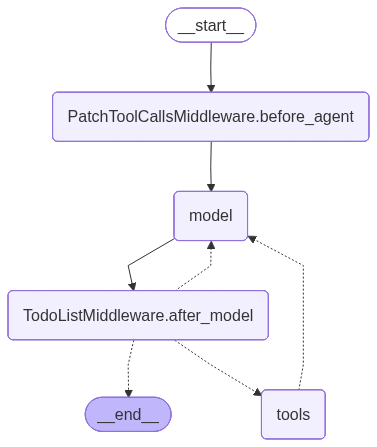

In [3]:
# (커널-Comm 전송) HTTP 서버 없이 — 커널에 직접 챗봇을 등록합니다.
#   원격/컨테이너(JupyterHub Pod, 8888만 열림)에서도 동작: 별도 포트(8765) 안 씀.
from jlab_sidebar_chatbot import register_chatbot_comm, unregister_chatbot_comm

register_chatbot_comm(provider="ollama", model="qwen3.5:0.8b", base_url=None)   # 호스트 Ollama 사용
# 모델 없이 전송만 점검(고정 응답 stub): register_chatbot_comm(base_url=None)
# 해제: unregister_chatbot_comm()
# → 우측 💬 탭에서 대화. 사이드바가 '이 노트북의 커널'에 Comm 으로 붙어 토큰 스트리밍.

## (선택) 자가진단 — LLM 없이 '고정 텍스트' Comm (복붙용)

`register_chatbot_comm` 도 LLM 도 안 쓰고 **표준 라이브러리 + ipykernel** 만으로 챗봇 Comm 을 등록해 고정 텍스트를 돌려줍니다. 사내망(폐쇄망)에서 **사이드바가 커널 Comm 으로 붙는지(=전송 경로)만** 점검할 때, 아래 셀을 그대로 복사-붙여넣기 하세요. (원본 파일: `comm_selftest_cell.py`)

> ②(register) 와 이 셀은 같은 target 을 등록하므로 **둘 중 하나만** 실행하세요. 이 셀을 실행했다면 💬 에 항상 '연결 OK' 고정 텍스트가 옵니다(모델 호출 없음).

In [6]:
# ============================================================================
# 🧪 자가진단용 '복붙' 셀 — LLM 없이 고정 텍스트를 돌려주는 챗봇 Comm
# ----------------------------------------------------------------------------
# 사내망(폐쇄망) JupyterLab 노트북 셀에 '이 파일 내용을 통째로' 복사-붙여넣기 해서
# 실행하세요. 패키지 함수(register_chatbot_comm)도, deepagents/LLM 도 전혀 안 씁니다.
# 표준 라이브러리 + ipykernel(Comm) 만으로 챗봇 Comm target 을 등록합니다.
#
# 목적: 우측 💬 사이드바가 '이 커널' 에 Comm 으로 붙는지(= 전송 경로)만 점검.
#       프론트가 보낸 메시지에 고정 텍스트를 토큰 스트리밍으로 돌려줍니다.
#       (전제: jlab-sidebar-chatbot 확장이 설치돼 우측 💬 탭이 보이는 상태)
# ============================================================================
import re
from IPython import get_ipython

# ⚠️ 프론트엔드(labextension)의 target_name 과 '반드시' 일치해야 합니다.
COMM_TARGET = "jlab_sidebar_chatbot"

# 돌려줄 고정 텍스트(마크다운 + 코드블록 — 렌더/복사버튼까지 같이 점검).
ANSWER = (
    "✅ 커널 Comm 연결 OK — 이 응답은 **LLM 없이** 고정 텍스트로 돌려준 것입니다.\n\n"
    "사이드바 💬 가 이 노트북 커널에 정상적으로 붙었다는 뜻입니다.\n\n"
    "```python\n"
    "def add(a, b):\n"
    "    return a + b\n\n"
    "print(add(1, 1))  # 2\n"
    "```\n"
)


def _on_open(comm, open_msg):
    """프론트가 comm 을 열 때 호출 — 핸들러를 붙이고 'ready' 를 보냅니다."""

    def _handler(msg):
        # 프론트가 보낸 페이로드는 msg['content']['data'] 에 들어 있습니다.
        data = (msg.get("content") or {}).get("data") or {}
        mtype = data.get("type")

        if mtype == "reset":  # 새 대화 — 여기선 상태가 없으니 확인만
            comm.send({"type": "reset_ok", "session_id": data.get("session_id", "default")})
            return

        if mtype == "message":  # 한 턴 — 고정 텍스트를 토큰 조각으로 흘린 뒤 done
            for piece in re.findall(r".{1,8}", ANSWER, re.S):
                comm.send({"type": "token", "text": piece})
            comm.send({"type": "done", "answer": ANSWER, "steps": []})
            return

        comm.send({"type": "error", "error": f"알 수 없는 type: {mtype!r}"})

    comm.on_msg(_handler)
    comm.send({"type": "ready"})  # 채널 살아있음 신호


# 현재 노트북 커널에 target 등록(같은 이름으로 다시 실행하면 교체됩니다).
_kernel = get_ipython().kernel
_kernel.comm_manager.register_target(COMM_TARGET, _on_open)
print(f"✅ 테스트 Comm 등록됨: target='{COMM_TARGET}' (LLM 없음 · 고정 텍스트).")
print("   우측 💬 탭에서 아무 메시지나 보내면 고정 텍스트가 토큰 스트리밍으로 옵니다.")
print("   해제: get_ipython().kernel.comm_manager.unregister_target('jlab_sidebar_chatbot', _on_open)")


✅ 테스트 Comm 등록됨: target='jlab_sidebar_chatbot' (LLM 없음 · 고정 텍스트).
   우측 💬 탭에서 아무 메시지나 보내면 고정 텍스트가 토큰 스트리밍으로 옵니다.
   해제: get_ipython().kernel.comm_manager.unregister_target('jlab_sidebar_chatbot', _on_open)


## ③ 모델·엔드포인트·시스템 프롬프트 바꾸기

`register_chatbot_comm(...)` 의 인자는 `build_chat_graph` 와 동일합니다. env 만 바꿔도 충분하지만, 셀에서 명시적으로 주려면:

```python
from jlab_sidebar_chatbot import register_chatbot_comm

# 사내 vLLM(OpenAI 호환) + 커스텀 프롬프트
register_chatbot_comm(
    api_key="<사내 키>", base_url="https://<사내 vllm host>/v1",
    model="<served-model-name>", system_prompt="너는 SQL 전문가야. 쿼리 위주로 답해.",
)

# 로컬 Ollama (키 불필요, 가장 빠르게)
register_chatbot_comm(provider="ollama", model="qwen3.5:0.8b")
```

- 멀티턴은 langgraph 체크포인터(`InMemorySaver`) + 세션(thread_id) 가 관리합니다. 💬 의 **새 대화** 버튼이 thread 를 분기해 기록을 비웁니다.
- 인자가 환경변수보다 우선합니다. 키를 셀에 적기 싫으면 `getpass.getpass()` 로 받으세요.
- 도구를 추가하는 등 그래프를 직접 만들려면 `build_chat_graph(...)` 로 만든 그래프를 쓰는 변형도 가능합니다.

## ④ 정리 — 챗봇 해제 & 익스텐션 삭제

데모가 끝나면 아래 셀로 챗봇 Comm 을 해제하고 패키지(프론트 labextension 포함)를 제거합니다. **jupyter 재시작 없이** 브라우저 새로고침만 하면 우측 💬 탭이 사라집니다.

In [ ]:
# (정리) 데모가 끝나면 챗봇 Comm 을 해제하고, 설치했던 익스텐션 패키지를 제거합니다.
from jlab_sidebar_chatbot import unregister_chatbot_comm
unregister_chatbot_comm()                 # 커널의 챗봇 Comm target 해제 (먼저 — uninstall 전에)

%pip uninstall -y jlab_sidebar_chatbot    # 프론트 labextension 자산 포함 패키지 삭제
# → 브라우저를 '새로고침'하면 우측 💬 탭이 사라집니다 (jupyter 서버 재시작 불필요)